In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const

plt.style.use('/Users/alexg/Python Projects/alex_style.mplstyle')
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'

from TeraToptica import TeraScanAnalyzer as TSA, TeraScanConfig as TSC

mask_bounds = (
              (0, 150), # mask low frequency data
              (545, 570), (740, 765), (1080, 1120), (1150, 1175), (1190, 1245), (1390, 1430), # mask waterlines
              (1585, 1810), (1855, 1950),
              (1500, 10000) # model does not converge above ~1500 GHz
              )

mask_starts = np.array((mask_bounds))[:,0]
mask_stops = np.array((mask_bounds))[:,1]

from pathlib import Path

BASE_DIR = Path.cwd()
TF_DIR = BASE_DIR / "data" / "TeraFlash"
TS_DIR = BASE_DIR / "data" / "TeraScan"

# TeraScan Example

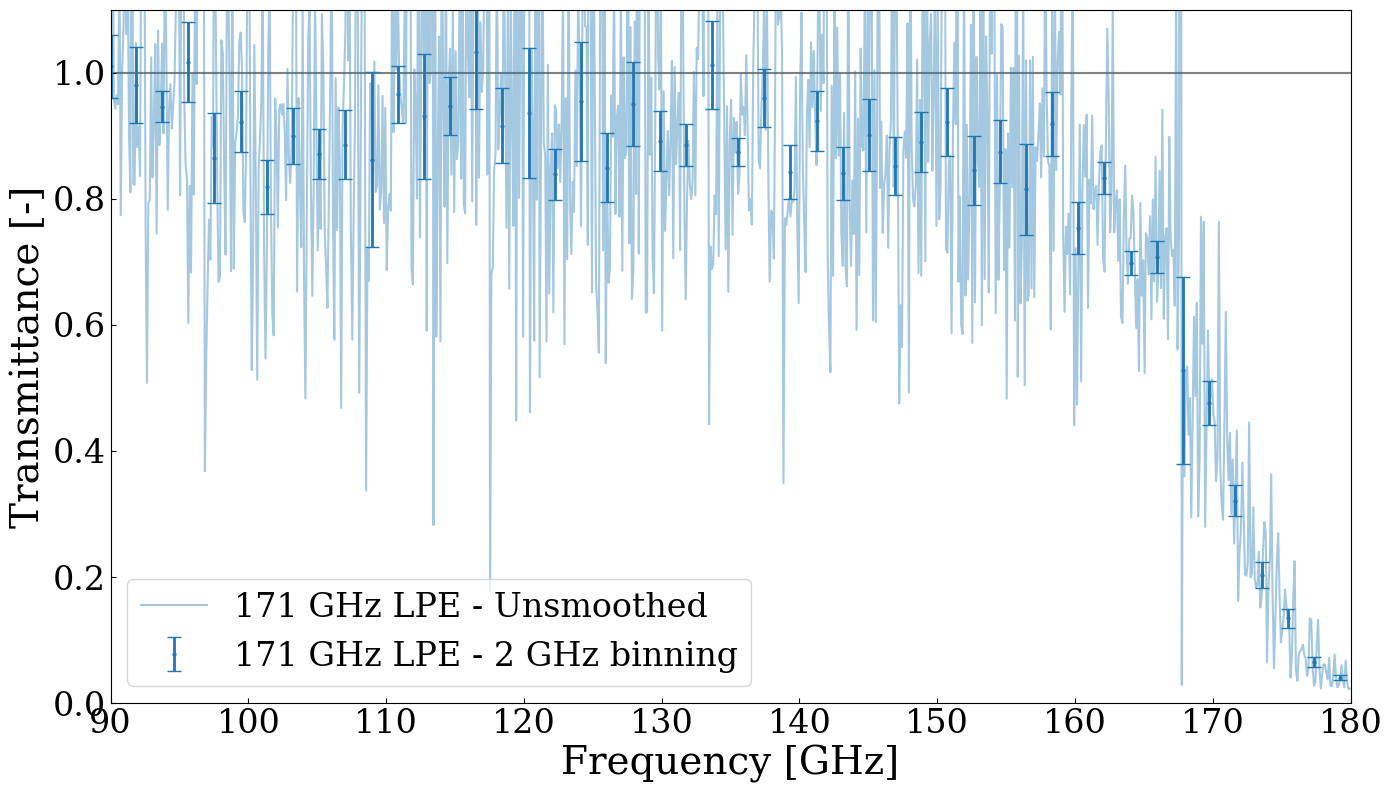

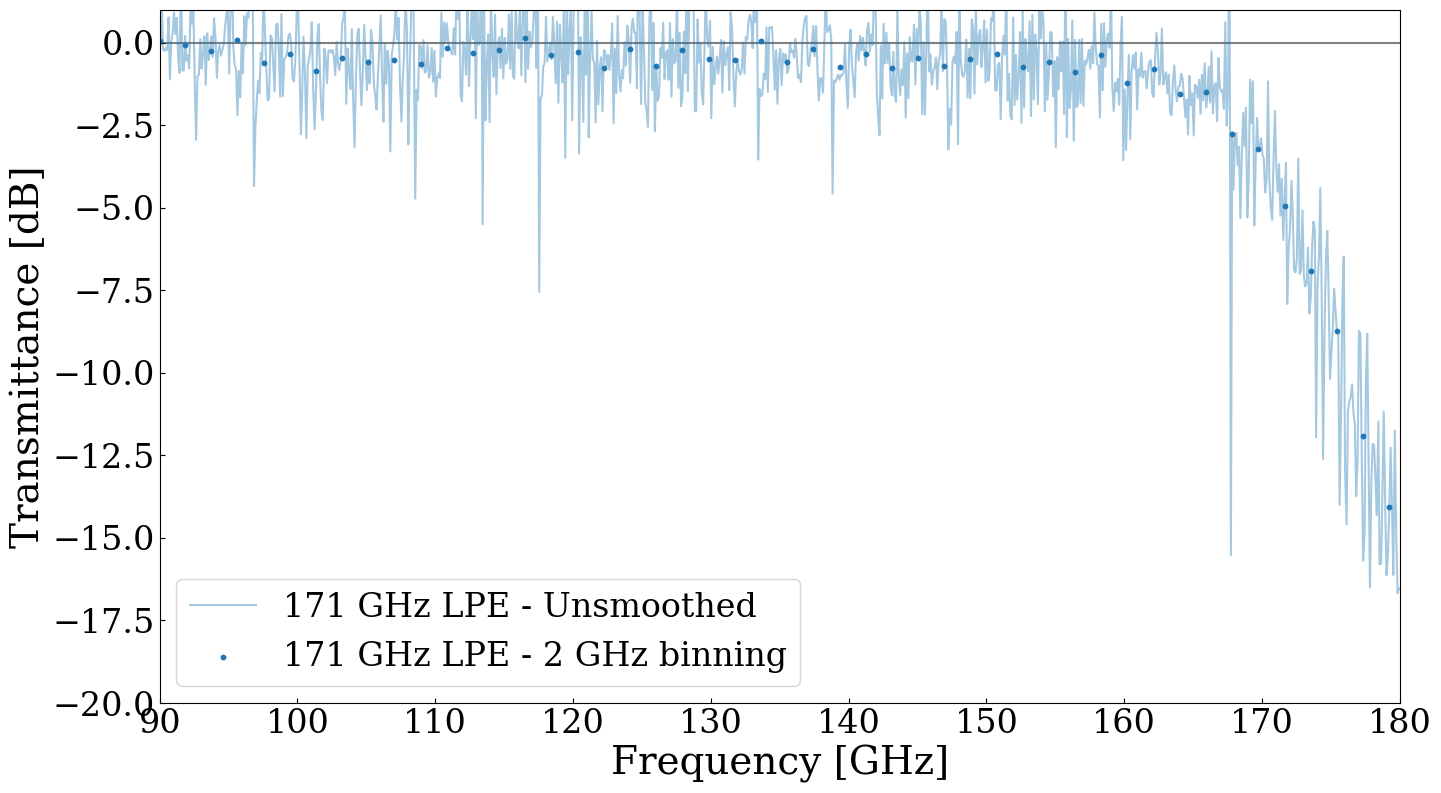

In [8]:
cfg_str = TSC(
    window='boxcar',
    window_size=2,
    mask_bounds=mask_bounds,
    include_mes_err=True,
    i_dc=14e-3,
    fiber_stretcher=True,    # <- Utilizes a fiber stretcher in the measurement setup
    open_stem=None,
)

ts = TSA(TS_DIR, 'LPE_5o7cm^-1_90-180ghz', 'open_90-180ghz', config=cfg_str)

f_LPE, t_LPE, ut_LPE, mask_LPE, err_LPE, boxnum_LPE = ts.get_smoothed_spectra()

ut_LPE_dB, t_LPE_dB = 10 * np.log10(ut_LPE), 10 * np.log10(t_LPE)

LPE_amp, base_amp = ts.get_currents()
LPE_pc, base_pc = ts.get_mod_currents()

plt.figure(figsize=(16, 9))

plt.plot(f_LPE, ut_LPE, alpha=0.4, color='tab:blue', label='171 GHz LPE - Unsmoothed')
plt.errorbar(f_LPE[::boxnum_LPE], t_LPE[::boxnum_LPE], yerr=err_LPE[::boxnum_LPE], 
             fmt='o', markersize=2, linewidth=2, capsize=5,
             color='tab:blue', label='171 GHz LPE - 2 GHz binning')
plt.axhline(1, color='gray', zorder=-1)

plt.xlabel('Frequency [GHz]')
plt.ylabel('Transmittance [-]')

plt.ylim(0, 1.1)
plt.xlim(90, 180)
plt.legend(loc='lower left', fontsize=24)
# plt.title('FP3697 Transmission Comparison')
plt.subplots_adjust(hspace=0.1)
plt.show()

plt.figure(figsize=(16, 9))

plt.plot(f_LPE, ut_LPE_dB, alpha=0.4, color='tab:blue', label='171 GHz LPE - Unsmoothed')
plt.scatter(f_LPE[::boxnum_LPE], t_LPE_dB[::boxnum_LPE], s=10, color='tab:blue', label='171 GHz LPE - 2 GHz binning')
plt.axhline(0, color='gray', zorder=-1)

plt.xlabel('Frequency [GHz]')
plt.ylabel('Transmittance [dB]')

plt.ylim(-20, 1)
plt.xlim(90, 180)
plt.legend(loc='lower left', fontsize=24)
# plt.title('FP3697 Transmission Comparison')
plt.subplots_adjust(hspace=0.1)
plt.show()
